<a href="https://colab.research.google.com/github/fawkes12345/LNDb-Multimodal/blob/main/notebooks/00_dataset_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LNDb v4 Dataset Audit

## Goal

Understand the structure of LNDb v4 before training any model.

Questions:

1. How many image-annotated nodules are available?
2. How many report-derived nodules are available?
3. How many matched image-report pairs are available?
4. How many image-only and report-only nodules exist?
5. Which semantic attributes are available?

In [3]:
import pandas as pd
import numpy as np

In [4]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
from pathlib import Path

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/LNDb-Multimodal"
)

DATA_ROOT = PROJECT_ROOT / "data"
METADATA_DIR = DATA_ROOT / "metadata"
CT_DIR = DATA_ROOT / "ct"

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

print("Project:", PROJECT_ROOT)
print("Metadata:", METADATA_DIR)
print("CT:", CT_DIR)

Project: /content/drive/MyDrive/LNDb-Multimodal
Metadata: /content/drive/MyDrive/LNDb-Multimodal/data/metadata
CT: /content/drive/MyDrive/LNDb-Multimodal/data/ct


In [6]:
for folder in [
    METADATA_DIR,
    CT_DIR,
    CHECKPOINT_DIR,
    OUTPUT_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Folders ready.")

Folders ready.


In [7]:
import requests
from pathlib import Path

RECORD_ID = "8348419"

FILES = [
    "report.csv",
    "allNods.csv",
    "chars_trainNodules.csv",
    "rad2Fleischner.csv",
    "text2Fleischner.csv",
    "help.txt",
]

host = "zenodo.org"

for filename in FILES:
    url = (
        "https://"
        + host
        + "/records/"
        + RECORD_ID
        + "/files/"
        + filename
    )

    destination = METADATA_DIR / filename

    if destination.exists():
        print(f"Already exists: {filename}")
        continue

    print(f"Downloading {filename}...")

    response = requests.get(url, stream=True)
    response.raise_for_status()

    with open(destination, "wb") as f:
        for chunk in response.iter_content(
            chunk_size=8192
        ):
            f.write(chunk)

    print(f"Saved to: {destination}")

Already exists: report.csv
Already exists: allNods.csv
Already exists: chars_trainNodules.csv
Already exists: rad2Fleischner.csv
Already exists: text2Fleischner.csv
Already exists: help.txt


In [8]:
for file in METADATA_DIR.iterdir():
    print(
        file.name,
        round(file.stat().st_size / 1024, 2),
        "KB"
    )

report.csv 23.61 KB
allNods.csv 158.55 KB
chars_trainNodules.csv 68.2 KB
rad2Fleischner.csv 54.27 KB
text2Fleischner.csv 27.97 KB
help.txt 2.29 KB


In [9]:
import pandas as pd

report_df = pd.read_csv(
    METADATA_DIR / "report.csv"
)

all_nodules_df = pd.read_csv(
    METADATA_DIR / "allNods.csv"
)

chars_df = pd.read_csv(
    METADATA_DIR / "chars_trainNodules.csv"
)

rad_df = pd.read_csv(
    METADATA_DIR / "rad2Fleischner.csv"
)

text_df = pd.read_csv(
    METADATA_DIR / "text2Fleischner.csv"
)

In [10]:
display(report_df.head())

,num_report,loc_0,unc_0,rem_0,loc_1,unc_1,rem_1,loc_2,unc_2,rem_2,loc_3,unc_3,rem_3,loc_4,unc_4,rem_4,loc_5,unc_5,rem_5
0,1,RUL,NaN,"apical,8.5,nod,margin: 1",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,"
1,2,LUL,how many?,",,nod,calcification: 5",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,"
2,3,NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,"
3,4,RUL,NaN,",11,nod,internalStructure: 3",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,"
4,5,LUL,how many?,",,micro,",UL,how many?,",,micro,",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,"


In [11]:
print(report_df.shape)
print(all_nodules_df.shape)

print(report_df.columns.tolist())
print(all_nodules_df.columns.tolist())

display(report_df.head())
display(all_nodules_df.head())

(292, 19)
(1234, 26)
['num_report', 'loc_0', 'unc_0', 'rem_0', 'loc_1', 'unc_1', 'rem_1', 'loc_2', 'unc_2', 'rem_2', 'loc_3', 'unc_3', 'rem_3', 'loc_4', 'unc_4', 'rem_4', 'loc_5', 'unc_5', 'rem_5']
['LNDbID', 'RadID', 'RadFinding', 'FindingID', 'Nodule', 'x', 'y', 'z', 'DiamEq_Rad', 'Texture', 'Calcification', 'InternalStructure', 'Lobulation', 'Malignancy', 'Margin', 'Sphericity', 'Spiculation', 'Subtlety', 'Lobe', 'TextInstanceID', 'TextQuestion', 'Pos_Text', 'Diam_Text', 'NodType', 'Caract_Text', 'Where']


,num_report,loc_0,unc_0,rem_0,loc_1,unc_1,rem_1,loc_2,unc_2,rem_2,loc_3,unc_3,rem_3,loc_4,unc_4,rem_4,loc_5,unc_5,rem_5
0,1,RUL,NaN,"apical,8.5,nod,margin: 1",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,"
1,2,LUL,how many?,",,nod,calcification: 5",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,"
2,3,NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,"
3,4,RUL,NaN,",11,nod,internalStructure: 3",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,"
4,5,LUL,how many?,",,micro,",UL,how many?,",,micro,",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,",NaN,NaN,",,,"


,LNDbID,RadID,RadFinding,FindingID,Nodule,x,y,z,DiamEq_Rad,Texture,...,Spiculation,Subtlety,Lobe,TextInstanceID,TextQuestion,Pos_Text,Diam_Text,NodType,Caract_Text,Where
0,1,"1,2,3","1,1,1",1,"1,1,1",-44.203451,-119.073242,-37.5,7.516572,5.0,...,2.333333,3.666667,3,0.0,NaN,apical,8.5,nod,margin: 1,TextReport+RadAnnotation
1,1,1,2,2,1,25.852539,-126.969727,-45.5,6.626905,4.0,...,1.000000,3.000000,1,NaN,NaN,NaN,NaN,NaN,NaN,RadAnnotation
2,2,"1,2,3","1,1,3",1,"1,1,1",88.895508,-123.867513,-129.5,8.971132,5.0,...,1.000000,5.000000,1,0.0,how many?,NaN,NaN,nod,calcification: 5,TextReport+RadAnnotation
3,2,"1,3","2,2",2,"1,1",63.534180,-112.756836,-117.5,6.937737,5.0,...,1.000000,5.000000,1,0.0,how many?,NaN,NaN,nod,calcification: 5,TextReport+RadAnnotation
4,2,"1,3","3,5",3,"1,1",-103.850586,-116.742188,-253.0,8.284458,5.0,...,1.000000,3.500000,5,NaN,NaN,NaN,NaN,NaN,NaN,RadAnnotation


In [12]:
all_nodules_df["Where"].value_counts(dropna=False)

,count
Where,
RadAnnotation,732
TextReport+RadAnnotation,377
TextReport (created: texture),47
TextReport+RadAnnotation (created: texture),43
"TextReport (created: size, texture)",17
TextReport,12
TextReport (created: size),6


In [13]:
all_nodules_df["Where"].unique()

array(['TextReport+RadAnnotation', 'RadAnnotation',
       'TextReport (created: size, texture)',
       'TextReport (created: texture)', 'TextReport',
       'TextReport+RadAnnotation (created: texture)',
       'TextReport (created: size)'], dtype=object)

In [14]:
num_cases = all_nodules_df["LNDbID"].nunique()

print("Number of CT cases:", num_cases)

Number of CT cases: 231


In [15]:
findings_per_case = (
    all_nodules_df
    .groupby("LNDbID")
    .size()
)

print(findings_per_case.describe())

count    231.000000
mean       5.341991
std        3.354415
min        1.000000
25%        3.000000
50%        5.000000
75%        7.000000
max       19.000000
dtype: float64


In [16]:
missing = (
    all_nodules_df
    .isna()
    .mean()
    .sort_values(ascending=False)
    * 100
)

display(missing)

,0
Caract_Text,90.842788
Pos_Text,84.359806
TextQuestion,82.333874
Diam_Text,73.987034
NodType,59.319287
TextInstanceID,59.319287
Lobulation,37.763371
InternalStructure,37.763371
Malignancy,37.763371
Sphericity,37.763371


In [17]:
print(all_nodules_df["Where"].unique())

display(
    all_nodules_df["Where"]
    .value_counts(dropna=False)
)

print(
    "Number of CT cases:",
    all_nodules_df["LNDbID"].nunique()
)

display(
    all_nodules_df
    .groupby("LNDbID")
    .size()
    .describe()
)

display(
    all_nodules_df
    .isna()
    .mean()
    .sort_values(ascending=False)
    * 100
)

['TextReport+RadAnnotation' 'RadAnnotation'
 'TextReport (created: size, texture)' 'TextReport (created: texture)'
 'TextReport' 'TextReport+RadAnnotation (created: texture)'
 'TextReport (created: size)']


,count
Where,
RadAnnotation,732
TextReport+RadAnnotation,377
TextReport (created: texture),47
TextReport+RadAnnotation (created: texture),43
"TextReport (created: size, texture)",17
TextReport,12
TextReport (created: size),6


Number of CT cases: 231


,0
count,231.000000
mean,5.341991
std,3.354415
min,1.000000
25%,3.000000
50%,5.000000
75%,7.000000
max,19.000000


,0
Caract_Text,90.842788
Pos_Text,84.359806
TextQuestion,82.333874
Diam_Text,73.987034
NodType,59.319287
TextInstanceID,59.319287
Lobulation,37.763371
InternalStructure,37.763371
Malignancy,37.763371
Sphericity,37.763371


## Initial Dataset Audit

The `allNods.csv` file contains:

- 1,234 finding records
- 231 unique LNDb CT IDs
- Mean findings per CT: 5.34
- Median findings per CT: 5
- Maximum findings in one CT: 19

The largest annotation groups are:

- RadAnnotation: 732
- TextReport+RadAnnotation: 377

For the first multimodal experiments, we will use a strict cohort consisting only of `TextReport+RadAnnotation` samples. Rows marked as `created: size` or `created: texture` will be analyzed separately before inclusion.

In [18]:
matched_df = all_nodules_df[
    all_nodules_df["Where"] == "TextReport+RadAnnotation"
].copy()

print("Strict matched findings:", len(matched_df))
print("Unique matched CT cases:", matched_df["LNDbID"].nunique())

Strict matched findings: 377
Unique matched CT cases: 155


In [19]:
semantic_cols = [
    "TextInstanceID",
    "TextQuestion",
    "Pos_Text",
    "Diam_Text",
    "NodType",
    "Caract_Text",
]

semantic_missing = (
    matched_df[semantic_cols]
    .isna()
    .mean()
    .mul(100)
    .sort_values()
)

display(semantic_missing)

,0
TextInstanceID,0.000000
NodType,0.000000
Diam_Text,35.278515
TextQuestion,54.376658
Pos_Text,62.599469
Caract_Text,80.371353


In [20]:
display(
    matched_df[
        [
            "LNDbID",
            "FindingID",
            "DiamEq_Rad",
            "Texture",
            "Lobe",
            "Pos_Text",
            "Diam_Text",
            "NodType",
            "Caract_Text",
            "Where",
        ]
    ].head(20)
)

,LNDbID,FindingID,DiamEq_Rad,Texture,Lobe,Pos_Text,Diam_Text,NodType,Caract_Text,Where
0,1,1,7.516572,5.0,3,apical,8.5,nod,margin: 1,TextReport+RadAnnotation
2,2,1,8.971132,5.0,1,NaN,NaN,nod,calcification: 5,TextReport+RadAnnotation
3,2,2,6.937737,5.0,1,NaN,NaN,nod,calcification: 5,TextReport+RadAnnotation
5,2,4,4.691901,3.0,1,NaN,NaN,nod,calcification: 5,TextReport+RadAnnotation
6,2,5,3.479254,4.0,1,NaN,NaN,nod,calcification: 5,TextReport+RadAnnotation
8,2,7,9.024803,4.0,1,NaN,NaN,nod,calcification: 5,TextReport+RadAnnotation
15,4,1,12.581763,5.0,3,NaN,11.0,nod,internalStructure: 3,TextReport+RadAnnotation
19,5,2,5.924913,5.0,1,NaN,NaN,micro,NaN,TextReport+RadAnnotation
26,8,1,5.839471,1.0,4,NaN,7.0,nod,texture: 1,TextReport+RadAnnotation
31,10,1,4.444191,5.0,5,posterior lateral justapleural,5.0,nod,NaN,TextReport+RadAnnotation


## Why We Construct the Strict Matched Cohort

The goal of this step is to identify the subset of LNDb v4 that can be reliably used for multimodal learning.

The full `allNods.csv` file contains several types of findings, including image-only annotations, report-only findings, matched image-report findings, and several derived (`created`) variants. For the first multimodal experiment, we intentionally use only:

```text
Where == "TextReport+RadAnnotation"
```

This creates a **strict matched cohort**, where each finding has both a radiologist image annotation and corresponding information derived from the medical report.

This conservative choice is important because it avoids introducing samples with derived or partially reconstructed attributes before we fully understand how those fields were generated.

### Why count matched findings?

```python
len(matched_df)
```

tells us how many image-report pairs are available for multimodal learning.

In this dataset:

```text
377 matched findings
```

are available in the strict cohort.

These findings can potentially provide positive pairs for future contrastive learning:

```text
3D CT nodule
      ↕
report-derived semantics
```

### Why count unique CT cases?

```python
matched_df["LNDbID"].nunique()
```

tells us how many independent CT scans contribute to the matched cohort.

There are:

```text
155 unique CT cases
```

This is important because train, validation, and test sets must later be split at the **CT case level**, rather than at the individual nodule level.

If nodules from the same CT scan appeared in both training and test sets, the model could see highly similar anatomical and acquisition information during training, creating data leakage.

Therefore, all findings from one `LNDbID` should remain in the same data split.

### Why examine missing semantic fields?

A finding can successfully match between the CT annotation and the medical report even if the report does not explicitly describe every possible characteristic.

For example, a report may mention:

```text
"right upper lobe pulmonary nodule"
```

without specifying:

```text
diameter
precise position
margin
texture
other characteristics
```

Therefore, we calculate the missing percentage of each report-derived semantic field.

The strict matched cohort contains:

```text
TextInstanceID    0.0% missing
NodType           0.0% missing
Diam_Text        35.3% missing
TextQuestion     54.4% missing
Pos_Text         62.6% missing
Caract_Text      80.4% missing
```

This shows that **successful image-report matching does not mean that every semantic attribute is available**.

`TextInstanceID` and `NodType` are available for all matched findings, while more detailed information such as position and specific characteristics is much more sparse.

This result is important for model design. We should not build a semantic encoder that assumes every sample contains size, position, texture, and morphological characteristics.

Instead, the future semantic representation will need to handle optional or missing information.

### Why inspect individual matched examples?

Displaying selected columns from the matched cohort allows us to directly compare the two modalities.

For example:

```text
CT annotation:
DiamEq_Rad = 7.52 mm

Medical report:
Diam_Text = 8.5 mm
```

The two values refer to the same matched nodule but are not exactly identical.

This is expected because:

- `DiamEq_Rad` is derived from the CT segmentation;
- `Diam_Text` is the diameter written by the radiologist in the clinical report.

Therefore, the two modalities represent related but not identical observations of the same lesion.

This difference is one of the central motivations for multimodal learning: different modalities may provide complementary and imperfect views of the same clinical object.

## Cross-Modal Agreement: Nodule Diameter

We first examine whether the nodule diameter measured from the CT annotation agrees with the diameter described in the medical report.

`DiamEq_Rad` represents the equivalent diameter derived from the radiologist's CT segmentation, while `Diam_Text` represents the diameter explicitly written in the medical report.

Because `Diam_Text` is missing for some matched findings, only samples with both measurements are included in this analysis.

In [21]:
diameter_df = matched_df[
    matched_df["Diam_Text"].notna()
].copy()

print("Matched nodules with both diameter measurements:")
print(len(diameter_df))

Matched nodules with both diameter measurements:
244


In [22]:
display(
    diameter_df[
        [
            "LNDbID",
            "FindingID",
            "DiamEq_Rad",
            "Diam_Text"
        ]
    ].head(20)
)

,LNDbID,FindingID,DiamEq_Rad,Diam_Text
0,1,1,7.516572,8.5
15,4,1,12.581763,11.0
26,8,1,5.839471,7.0
31,10,1,4.444191,5.0
32,10,2,5.209962,7.0
35,10,5,3.827670,7.0
51,13,1,3.321178,8.0
54,13,4,5.102982,4.0
60,15,1,4.766817,4.0
62,15,3,4.475411,5.0


In [23]:
diameter_df["Diameter_Difference"] = (
    diameter_df["Diam_Text"]
    - diameter_df["DiamEq_Rad"]
)

diameter_df["Absolute_Difference"] = (
    diameter_df["Diameter_Difference"].abs()
)

display(
    diameter_df[
        [
            "DiamEq_Rad",
            "Diam_Text",
            "Diameter_Difference",
            "Absolute_Difference"
        ]
    ].head(20)
)

,DiamEq_Rad,Diam_Text,Diameter_Difference,Absolute_Difference
0,7.516572,8.5,0.983428,0.983428
15,12.581763,11.0,-1.581763,1.581763
26,5.839471,7.0,1.160529,1.160529
31,4.444191,5.0,0.555809,0.555809
32,5.209962,7.0,1.790038,1.790038
35,3.827670,7.0,3.172330,3.172330
51,3.321178,8.0,4.678822,4.678822
54,5.102982,4.0,-1.102982,1.102982
60,4.766817,4.0,-0.766817,0.766817
62,4.475411,5.0,0.524589,0.524589


In [24]:
print(
    "Mean absolute difference:",
    diameter_df["Absolute_Difference"].mean()
)

print(
    "Median absolute difference:",
    diameter_df["Absolute_Difference"].median()
)

print(
    "Maximum absolute difference:",
    diameter_df["Absolute_Difference"].max()
)

Mean absolute difference: 1.3342719550760263
Median absolute difference: 0.9749687690334325
Maximum absolute difference: 5.800973403229413


In [25]:
correlation = diameter_df[
    ["DiamEq_Rad", "Diam_Text"]
].corr().iloc[0, 1]

print("Pearson correlation:", correlation)

Pearson correlation: 0.9267741191834186


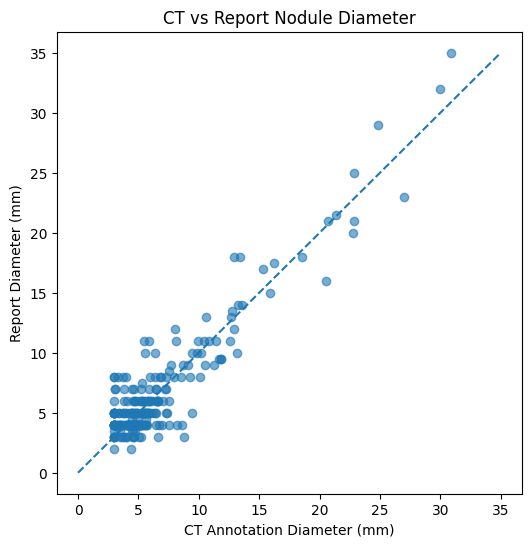

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.scatter(
    diameter_df["DiamEq_Rad"],
    diameter_df["Diam_Text"],
    alpha=0.6
)

max_value = max(
    diameter_df["DiamEq_Rad"].max(),
    diameter_df["Diam_Text"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("CT Annotation Diameter (mm)")
plt.ylabel("Report Diameter (mm)")
plt.title("CT vs Report Nodule Diameter")

plt.show()